In [2]:
import numpy as np
import matplotlib.pyplot as plt

A 1D quantum particle is bound in a finite square well potential $V_0$ in its first excited state. \
We are given that:

$\theta=a\sin\theta \implies f(x)=\theta-a\sin\theta$ 

Where $\theta\propto\sqrt E$ and $a\propto\sqrt V_0$. Also, $\pi/2<\theta<\pi$. 

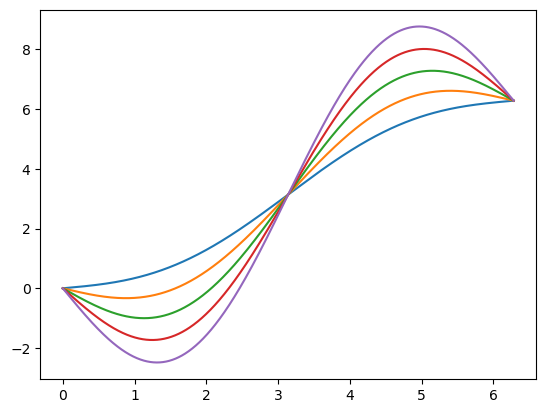

In [3]:
for i in range(1, 6):
    a = i*np.pi/4
    x = np.linspace(0, 2*np.pi, 1000)
    f = x-a*np.sin(x)
    
    plt.plot(x, f, label=f'f(x), a={np.round(a, 3)}')

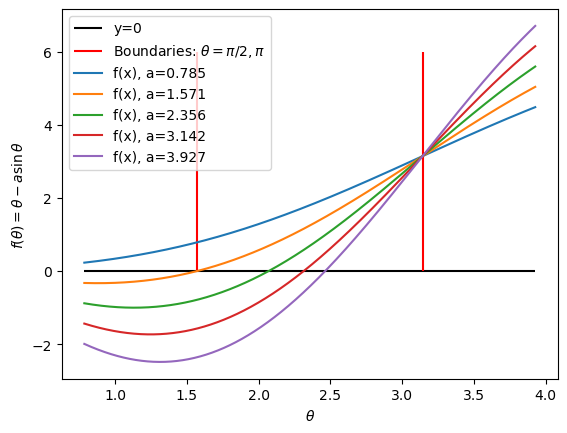

In [2]:
# Plotting the function 

plt.hlines(0, np.pi/4, (5/4)*np.pi, color='k', label='y=0')
plt.vlines(np.pi/2, 0, 6, color='red', label=r'Boundaries: $\theta=\pi/2, \pi$')
plt.vlines(np.pi, 0, 6, color='red')

for i in range(1, 6):
    a = i*np.pi/4
    x = np.linspace(np.pi/4, (5/4)*np.pi, 1000)
    f = x-a*np.sin(x)
    
    plt.plot(x, f, label=f'f(x), a={np.round(a, 3)}')
    
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta) = \theta-a\sin\theta$')
plt.legend()
plt.show()

We know that at $\theta=\pi/2 \implies f(\pi/2)=(\pi/2-a)$ and at $\theta=\pi \implies f(\pi)=\pi$. Hence, a root will only exist if $a>=\pi/2$ otherwise the function will not change sign within the range. We can now use the bisection method to find the roots by using the bounds on $\theta$ as the upper and lower limits. 

In [6]:
# Bisection Method of Finding Roots
def f(x, a): 
    return x-a*np.sin(x) 

def Bisection(f, a_0, U, L, eps=1e-6, max_iter=1000):

    # Return error if f(U) and f(L) have the same sign
    if f(U, a_0)*f(L, a_0) > 0:
        raise ValueError("No root in range")
    
    while abs(U-L)/2 > eps and max_iter >= 0:
        t = (U+L)/2
        # If f(t) = 0, t is the root
        if f(t, a_0) == 0:
            return t
        # Check which side f(t) lies on
        if f(t, a_0)*f(L, a_0) < 0:
            U = t
        else:
            L = t
        max_iter -= 1
    return t

In [4]:
a0 = np.pi/2
theta0 = Bisection(f, a0, np.pi/2, np.pi)

print(f'Root = {theta0}')

Root = 1.5707978248230097


This bisection method can determine the roots of $f(x)$. Running this across values of a, we can find the critcal point:

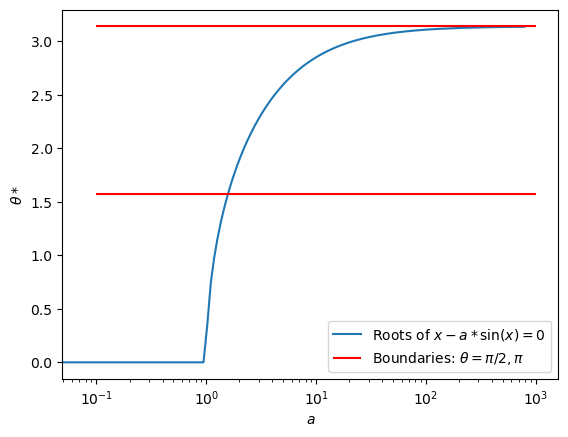

In [5]:
# theta roots vs a
x = np.linspace(0, 1000, 10000)
a = x*np.pi/4
theta = np.zeros(len(a))

for i in range(len(a)):
    theta[i] = Bisection(f, a[i], 0, np.pi)

plt.plot(a, theta, label=r'Roots of $x-a*\sin(x)=0$')
plt.hlines(np.pi/2, 10**-1, 10**3, color='red', label=r'Boundaries: $\theta=\pi/2, \pi$')
plt.hlines(np.pi, 10**-1, 10**3, color='red')
plt.xscale('log')
plt.xlabel(r'$a$')
plt.ylabel(r'$\theta*$')
plt.legend(loc='lower right')
plt.show()

Since $E \propto \theta^2$, the energy will only be defined as long as $\theta$ is real. From the above graph, we note that for large a, the root asymptotes to $\theta^*=\pi$ and is therefore always defined in the boundaries. However, at $\theta^*=\pi/2$, $a$ has a critical value which can be solved for: 

$\frac{\pi}{2} = a_c*\sin(\frac{\pi}{2})$ \
$\implies a_c = \frac{\pi}{2}$

Hence, when $a<a_c$ then $(\theta-a\sin\theta)=0$ has no roots within the boundaries and therefore does not have a first excited state with a well-defined energy. 

We can also understand this in physical terms since $E \propto \theta^2 \implies E = k_1\theta^2$ and $V_0 \propto a^2 \implies V_0 = k_2 a^2$. When $E>V_0$, the energy of the particle is greater than the potential well and will therefore not yield a bound state. However, as long as $E<V_0$ (i.e. $\theta < a$), a bound state will be found with a well-defined energy. This gives us a critical point at $E=V_0 \implies k_2a_c^2=k_1\theta_c^2$. We know that $a_c=\theta_c=\pi/2$, which gives us additional information about the constants of proportionality: $k_1=k_2$.

Therefore, when $\theta < \pi/2$, the system will yield a scattering state whereas when $\theta > \pi/2$, it will give a bound state where the energy $E\propto\theta^2$ which is given by the roots of $(\theta-a\sin\theta)=0$.